Predicting Taxi Fare from Distance


In [26]:
import pandas as pd  
import seaborn as sns    
import matplotlib.pyplot as plt                        # pandas: read and handle tabular data
from sklearn.model_selection import train_test_split  # to split data into train/test parts
from sklearn.linear_model import LinearRegression      # the simple linear regression model
from sklearn.metrics import r2_score, mean_squared_error  # metrics to evaluate model
import warnings                                   # to remove the warning which appears at the output
warnings.filterwarnings("ignore")

In [16]:
df=pd.read_csv("C:/Users/varsh/Downloads/regression_datasets_large.xlsx - Taxi_Fare.csv")
print(df.isnull().sum())
print(df.columns)
df.duplicated().sum()

Trip_ID          0
Distance_km      0
Fare_Rs          0
Duration_min     0
Traffic_Level    0
Driver_Rating    0
Payment_Type     0
Day_of_Week      0
Time_of_Day      0
Weather          0
dtype: int64
Index(['Trip_ID', 'Distance_km', 'Fare_Rs', 'Duration_min', 'Traffic_Level',
       'Driver_Rating', 'Payment_Type', 'Day_of_Week', 'Time_of_Day',
       'Weather'],
      dtype='object')


np.int64(0)

In [17]:
df.head()

,Trip_ID,Distance_km,Fare_Rs,Duration_min,Traffic_Level,Driver_Rating,Payment_Type,Day_of_Week,Time_of_Day,Weather
0,1,9.735319,116.472746,44.746874,High,4.563782,Wallet,Fri,Afternoon,Rainy
1,2,10.326559,400.736005,98.813482,Low,4.531717,Cash,Fri,Night,Clear
2,3,20.979714,295.256653,58.673731,High,4.383311,Wallet,Tue,Afternoon,Clear
3,4,31.169312,190.422112,13.823125,High,4.931278,Wallet,Sun,Night,Rainy
4,5,2.717575,169.682559,24.096040,Low,3.787111,Card,Fri,Evening,Rainy


In [19]:
X=df[["Distance_km"]]                         # feature matrix (2D): distance is the input to the model
y=df["Fare_Rs"]                               

In [20]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)      # 20%-test; random_state makes the split reproducible)

model=LinearRegression()                      # create a LinearRegression object
model.fit(X_train,y_train)                     # learn slope (₹/km) and intercept (base fare) from training data


LinearRegression()

In [21]:
y_pred=model.predict(X_test)                  # model makes predictions for X_test

print("Mean Squared Error:", mean_squared_error(y_test, y_pred)) # average squared error (smaller is better)


Mean Squared Error: 48209.56566959557


In [22]:
trip_distance = float(input("Enter trip distance in km: "))

predicted_fare = model.predict([[trip_distance]])[0]  # Predict fare for that distance

print(f"Predicted Fare for {trip_distance} km trip: ₹{predicted_fare:.2f}")

Predicted Fare for 15.0 km trip: ₹465.49


In [23]:
print(f"Estimated Base Fare (Fixed Cost): ₹{model.intercept_:.2f}")
print(f"Fare per km (Rate): ₹{model.coef_[0]:.2f} per km")

Estimated Base Fare (Fixed Cost): ₹443.51
Fare per km (Rate): ₹1.47 per km


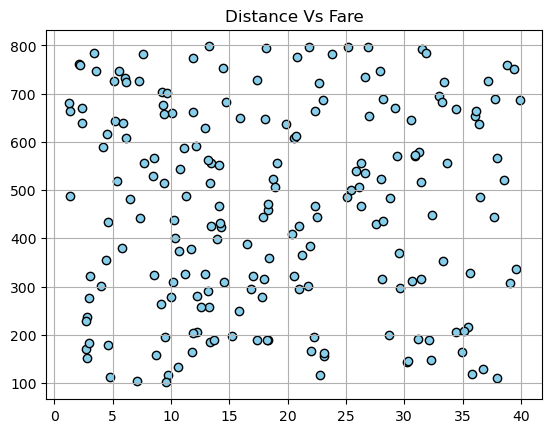

In [50]:
plt.scatter(X,y, color="Skyblue", edgecolors="black")
plt.title("Distance Vs Fare")
plt.grid(True)
plt.show()

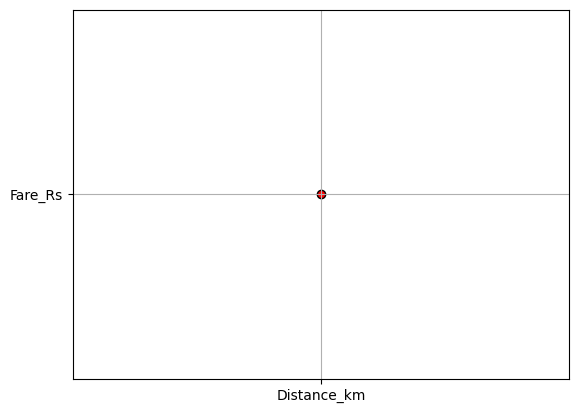

In [49]:
plt.scatter(["Distance_km"],["Fare_Rs"],color="red", edgecolors="black")
plt.grid()
plt.show()